# EXPERIMENTS: ADVANCED EDGE DETECTION & FEATURE SELECTION
## Parkinson's Spiral Classification with Multiple Edge Detection Methods & RFE

**Improvements over original paper:**
1. Multiple edge detection techniques: Canny, Sobel, Prewitt, Laplacian, Roberts
2. Recursive Feature Elimination (RFE) for feature selection
3. Recursive Feature Selection (RFS) across all models
4. Extended feature set: Original 11 + FFT + Entropy + LBP (14 total)
5. Feature importance analysis and visualization
6. Results saved to `/results/new-v2` directory

In [1]:
import numpy as np
import cv2
from pathlib import Path
import kagglehub
from scipy import stats
from scipy.fftpack import fft2, fftfreq
from skimage.feature import hog, local_binary_pattern
from skimage import filters
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print("All libraries imported successfully!")

All libraries imported successfully!


## SECTION 1: DATA LOADING & PREPROCESSING (Reused from Original Paper)

In [2]:
def cmgy_to_grayscale(img):
    """Convert CMGY format image to grayscale directly (no RGB intermediate)"""
    if len(img.shape) == 3 and img.shape[2] == 4:
        c = img[:, :, 0].astype(np.float32)
        m = img[:, :, 1].astype(np.float32)
        g = img[:, :, 2].astype(np.float32)
        y = img[:, :, 3].astype(np.float32)
        gray = (0.3 * c + 0.3 * m + 0.2 * g + 0.2 * y).astype(np.uint8)
        return gray
    else:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        return gray

# Download dataset
dataset_path = kagglehub.dataset_download("kmader/parkinsons-drawings")
print(f"Dataset downloaded to: {dataset_path}")

dataset_root = Path(dataset_path)

# Load training images
training_dir = dataset_root / 'spiral' / 'training'
train_images = []
train_labels = []

healthy_dir = training_dir / 'healthy'
for img_file in sorted(healthy_dir.glob('*.png')):
    img = cv2.imread(str(img_file), cv2.IMREAD_UNCHANGED)
    if img is not None:
        img = cmgy_to_grayscale(img)
        img = cv2.resize(img, (128, 128))
        train_images.append(img)
        train_labels.append(0)

parkinson_dir = training_dir / 'parkinson'
for img_file in sorted(parkinson_dir.glob('*.png')):
    img = cv2.imread(str(img_file), cv2.IMREAD_UNCHANGED)
    if img is not None:
        img = cmgy_to_grayscale(img)
        img = cv2.resize(img, (128, 128))
        train_images.append(img)
        train_labels.append(1)

X_train = np.array(train_images, dtype=np.uint8)
y_train = np.array(train_labels)

# Load testing images
testing_dir = dataset_root / 'spiral' / 'testing'
test_images = []
test_labels = []

healthy_dir = testing_dir / 'healthy'
for img_file in sorted(healthy_dir.glob('*.png')):
    img = cv2.imread(str(img_file), cv2.IMREAD_UNCHANGED)
    if img is not None:
        img = cmgy_to_grayscale(img)
        img = cv2.resize(img, (128, 128))
        test_images.append(img)
        test_labels.append(0)

parkinson_dir = testing_dir / 'parkinson'
for img_file in sorted(parkinson_dir.glob('*.png')):
    img = cv2.imread(str(img_file), cv2.IMREAD_UNCHANGED)
    if img is not None:
        img = cmgy_to_grayscale(img)
        img = cv2.resize(img, (128, 128))
        test_images.append(img)
        test_labels.append(1)

X_test = np.array(test_images, dtype=np.uint8)
y_test = np.array(test_labels)

# Normalize to [0, 1]
X_train = X_train.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0

print(f"\nTraining set shape: {X_train.shape}")
print(f"Training labels: Healthy={np.sum(y_train == 0)}, Parkinson's={np.sum(y_train == 1)}")
print(f"Testing set shape: {X_test.shape}")
print(f"Testing labels: Healthy={np.sum(y_test == 0)}, Parkinson's={np.sum(y_test == 1)}")

Dataset downloaded to: C:\Users\cefalo\.cache\kagglehub\datasets\kmader\parkinsons-drawings\versions\1

Training set shape: (72, 128, 128)
Training labels: Healthy=36, Parkinson's=36
Testing set shape: (30, 128, 128)
Testing labels: Healthy=15, Parkinson's=15


In [3]:
def augment_image(image, num_augmentations=71):
    """Generate augmented versions of a single image."""
    augmented_images = []
    h, w = image.shape[:2]
    augmented_images.append(image.copy())
    
    for _ in range(num_augmentations - 1):
        img = image.copy()
        angle = np.random.uniform(0, 360)
        center = (w // 2, h // 2)
        rotation_matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
        img = cv2.warpAffine(img, rotation_matrix, (w, h), borderMode=cv2.BORDER_REFLECT)
        
        shift_x = int(np.random.uniform(-0.01 * w, 0.01 * w))
        shift_y = int(np.random.uniform(-0.01 * h, 0.01 * h))
        translation_matrix = np.float32([[1, 0, shift_x], [0, 1, shift_y]])
        img = cv2.warpAffine(img, translation_matrix, (w, h), borderMode=cv2.BORDER_REFLECT)
        
        if np.random.rand() > 0.5:
            img = cv2.flip(img, 1)
        if np.random.rand() > 0.5:
            img = cv2.flip(img, 0)
        
        augmented_images.append(img)
    return augmented_images

# Create augmented training dataset
print("\nGenerating augmented images (71 per original image)...")
X_train_augmented = []
y_train_augmented = []

for idx, (image, label) in enumerate(zip(X_train, y_train)):
    if image.dtype == np.float32 or image.dtype == np.float64:
        image_uint8 = (image * 255).astype(np.uint8)
    else:
        image_uint8 = image.astype(np.uint8)
    
    augmented_imgs = augment_image(image_uint8, num_augmentations=71)
    for aug_img in augmented_imgs:
        X_train_augmented.append(aug_img.astype(np.float32) / 255.0)
        y_train_augmented.append(label)
    
    if (idx + 1) % 10 == 0:
        print(f"  Processed {idx + 1}/72 images...")

X_train_augmented = np.array(X_train_augmented, dtype=np.float32)
y_train_augmented = np.array(y_train_augmented)

print(f"✓ Augmented training dataset: {X_train_augmented.shape}")
print(f"  Healthy: {np.sum(y_train_augmented == 0)}, Parkinson's: {np.sum(y_train_augmented == 1)}")


Generating augmented images (71 per original image)...
  Processed 10/72 images...
  Processed 20/72 images...
  Processed 30/72 images...
  Processed 40/72 images...
  Processed 50/72 images...
  Processed 60/72 images...
  Processed 70/72 images...
✓ Augmented training dataset: (5112, 128, 128)
  Healthy: 2556, Parkinson's: 2556


## SECTION 2: EXTRACT 11 ORIGINAL FEATURES & CREATE BASELINE

In [4]:
def extract_hog_features(gray_img):
    """Extract HOG visualization from grayscale image"""
    if gray_img.dtype == np.float32 or gray_img.dtype == np.float64:
        img_uint8 = (gray_img * 255).astype(np.uint8)
    else:
        img_uint8 = gray_img
    
    hog_features, hog_image = hog(
        img_uint8,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        visualize=True,
        channel_axis=None
    )
    return hog_image

def extract_11_features(image):
    """Extract exactly 11 statistical features from a grayscale image"""
    flat = image.flatten()
    features = np.zeros(11)
    
    features[0] = np.mean(flat)
    features[1] = np.std(flat)
    features[2] = stats.skew(flat)
    features[3] = stats.kurtosis(flat)
    features[4] = np.sum(flat ** 2)
    features[5] = np.mean(flat ** 2)
    features[6] = np.median(flat)
    features[7] = np.var(flat)
    features[8] = np.min(flat)
    features[9] = np.max(flat)
    features[10] = np.sqrt(np.mean(flat ** 2))
    
    return features

# Create baseline: Raw images -> HOG -> 11 features
print("\n" + "="*80)
print("CREATING BASELINE DATASET: Raw Images + HOG + 11 Features")
print("="*80)

print("\nProcessing raw training images with HOG...")
hog_raw_images = []
for idx, image in enumerate(X_train):
    img_uint8 = (image * 255).astype(np.uint8)
    hog_img = extract_hog_features(img_uint8)
    hog_raw_images.append(hog_img)
    if (idx + 1) % 20 == 0:
        print(f"  Processed {idx + 1}/72 images...")

print("Extracting 11 features from HOG images...")
baseline_raw_features = np.array([extract_11_features(img) for img in hog_raw_images])
print(f"✓ Baseline (Raw + HOG): {baseline_raw_features.shape}")

# Create augmented version
print("\nProcessing augmented training images with HOG...")
hog_aug_images = []
for idx, image in enumerate(X_train_augmented):
    img_uint8 = (image * 255).astype(np.uint8)
    hog_img = extract_hog_features(img_uint8)
    hog_aug_images.append(hog_img)
    if (idx + 1) % 1000 == 0:
        print(f"  Processed {idx + 1}/{len(X_train_augmented)} images...")

print("Extracting 11 features from augmented HOG images...")
baseline_aug_features = np.array([extract_11_features(img) for img in hog_aug_images])
print(f"✓ Baseline Augmented (Aug + HOG): {baseline_aug_features.shape}")

print("="*80)


CREATING BASELINE DATASET: Raw Images + HOG + 11 Features

Processing raw training images with HOG...
  Processed 20/72 images...
  Processed 40/72 images...
  Processed 60/72 images...
Extracting 11 features from HOG images...
✓ Baseline (Raw + HOG): (72, 11)

Processing augmented training images with HOG...
  Processed 1000/5112 images...
  Processed 2000/5112 images...
  Processed 3000/5112 images...
  Processed 4000/5112 images...
  Processed 5000/5112 images...
Extracting 11 features from augmented HOG images...
✓ Baseline Augmented (Aug + HOG): (5112, 11)


## SECTION 2B: MULTIPLE EDGE DETECTION TECHNIQUES


In [5]:
def apply_canny(gray_img, sigma=2.8, threshold1=51, threshold2=51, apertureSize=5):
    """Canny edge detection"""
    if gray_img.dtype == np.float32 or gray_img.dtype == np.float64:
        img_uint8 = (gray_img * 255).astype(np.uint8)
    else:
        img_uint8 = gray_img
    
    img_smooth = cv2.GaussianBlur(img_uint8, (5, 5), sigma)
    edges = cv2.Canny(img_smooth, threshold1, threshold2, apertureSize=apertureSize)
    return edges.astype(np.float32) / 255.0

def apply_sobel(gray_img):
    """Sobel edge detection"""
    if gray_img.dtype == np.float32 or gray_img.dtype == np.float64:
        img_uint8 = (gray_img * 255).astype(np.uint8)
    else:
        img_uint8 = gray_img
    
    img_smooth = cv2.GaussianBlur(img_uint8, (5, 5), 1.0)
    sobelx = cv2.Sobel(img_smooth, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(img_smooth, cv2.CV_64F, 0, 1, ksize=3)
    edges = np.sqrt(sobelx**2 + sobely**2)
    edges = (edges / edges.max() * 255).astype(np.uint8) if edges.max() > 0 else edges
    return edges.astype(np.float32) / 255.0

def apply_prewitt(gray_img):
    """Prewitt edge detection"""
    if gray_img.dtype == np.float32 or gray_img.dtype == np.float64:
        img_uint8 = (gray_img * 255).astype(np.uint8)
    else:
        img_uint8 = gray_img
    
    img_smooth = cv2.GaussianBlur(img_uint8, (5, 5), 1.0)
    edges = filters.prewitt(img_smooth)
    return edges.astype(np.float32) / (edges.max() + 1e-8)

def apply_laplacian(gray_img):
    """Laplacian edge detection"""
    if gray_img.dtype == np.float32 or gray_img.dtype == np.float64:
        img_uint8 = (gray_img * 255).astype(np.uint8)
    else:
        img_uint8 = gray_img
    
    img_smooth = cv2.GaussianBlur(img_uint8, (5, 5), 1.0)
    laplacian = cv2.Laplacian(img_smooth, cv2.CV_64F)
    edges = np.abs(laplacian)
    edges = (edges / edges.max() * 255).astype(np.uint8) if edges.max() > 0 else edges
    return edges.astype(np.float32) / 255.0

def apply_roberts(gray_img):
    """Roberts edge detection"""
    if gray_img.dtype == np.float32 or gray_img.dtype == np.float64:
        img_uint8 = (gray_img * 255).astype(np.uint8)
    else:
        img_uint8 = gray_img
    
    img_smooth = cv2.GaussianBlur(img_uint8, (5, 5), 1.0)
    edges = filters.roberts(img_smooth)
    return edges.astype(np.float32) / (edges.max() + 1e-8)

print("✓ All edge detection functions defined")

✓ All edge detection functions defined


## SECTION 3: EXTENDED FEATURE EXTRACTION (11 + FFT + Entropy + LBP = 14 features)

In [6]:
def extract_14_features(image):
    """
    Extract 14 statistical and texture features from a grayscale image.
    
    Features 0-10: Original 11 features from paper
    Feature 11: FFT (Fourier magnitude sum)
    Feature 12: Shannon Entropy (texture complexity)
    Feature 13: LBP Histogram (Local Binary Pattern - rotation invariant)
    """
    flat = image.flatten()
    features = np.zeros(14)
    
    # Original 11 features
    features[0] = np.mean(flat)                    # Mean
    features[1] = np.std(flat)                     # Std Dev
    features[2] = stats.skew(flat)                 # Skewness
    features[3] = stats.kurtosis(flat)             # Kurtosis
    features[4] = np.sum(flat ** 2)                # Energy
    features[5] = np.mean(flat ** 2)               # Power
    features[6] = np.median(flat)                  # Median
    features[7] = np.var(flat)                     # Variance
    features[8] = np.min(flat)                     # Min
    features[9] = np.max(flat)                     # Max
    features[10] = np.sqrt(np.mean(flat ** 2))     # RMS
    
    # Feature 11: FFT - Fourier magnitude (frequency domain)
    # Captures spiral tremor frequencies in frequency domain
    if image.size > 0:
        fft_result = np.abs(fft2(image))
        # Focus on middle frequencies (remove DC and very high freq noise)
        fft_center = fft_result[fft_result.shape[0]//4:-fft_result.shape[0]//4, 
                                fft_result.shape[1]//4:-fft_result.shape[1]//4]
        features[11] = np.mean(fft_center) if fft_center.size > 0 else 0
    
    # Feature 12: Shannon Entropy - measure of texture complexity
    # Higher entropy = more complex/irregular patterns (indicator of Parkinson's)
    hist, _ = np.histogram(flat, bins=256, range=(0, 1))
    hist = hist[hist > 0]  # Remove zero bins
    hist = hist / hist.sum()  # Normalize to probability
    features[12] = -np.sum(hist * np.log2(hist + 1e-8))  # Shannon entropy
    
    # Feature 13: LBP Histogram - Local Binary Pattern with rotation invariance
    # Excellent for texture analysis, captures local patterns in spirals
    img_uint8 = (image * 255).astype(np.uint8) if image.max() <= 1 else image.astype(np.uint8)
    lbp = local_binary_pattern(img_uint8, P=8, R=1, method='uniform')
    lbp_hist, _ = np.histogram(lbp, bins=np.arange(0, 60), range=(0, 60))
    # Use the most significant LBP feature (max count in histogram)
    features[13] = np.max(lbp_hist) if len(lbp_hist) > 0 else 0
    
    return features

print("✓ Feature extraction function (14 features) defined")

✓ Feature extraction function (14 features) defined


## SECTION 4: CREATE DATASETS WITH ALL EDGE DETECTION METHODS

In [7]:
print("="*80)
print("CREATING DATASETS WITH MULTIPLE EDGE DETECTION METHODS")
print("="*80)

edge_detection_methods = {
    'Canny': apply_canny,
    'Sobel': apply_sobel,
    'Prewitt': apply_prewitt,
    'Laplacian': apply_laplacian,
    'Roberts': apply_roberts
}

# Store datasets: {method_name: (features, labels)}
datasets = {}

for method_name, edge_func in edge_detection_methods.items():
    print(f"\n--- Processing {method_name} Edge Detection ---")
    
    # Apply edge detection to raw training images
    edge_images = []
    for idx, image in enumerate(X_train):
        if image.dtype == np.float32 or image.dtype == np.float64:
            image_uint8 = (image * 255).astype(np.uint8)
        else:
            image_uint8 = image.astype(np.uint8)
        
        edge_img = edge_func(image_uint8)
        edge_images.append(edge_img)
        
        if (idx + 1) % 20 == 0:
            print(f"  Processed {idx + 1}/72 raw images...")
    
    # Extract 14 features from edge-detected images
    print(f"Extracting 14 features from {method_name} edge images...")
    features = np.array([extract_14_features(img) for img in edge_images])
    datasets[f'{method_name}_Raw'] = (features, y_train)
    print(f"✓ {method_name}_Raw: {features.shape}")
    
    # Apply edge detection to augmented training images
    edge_images_aug = []
    for idx, image in enumerate(X_train_augmented):
        if image.dtype == np.float32 or image.dtype == np.float64:
            image_uint8 = (image * 255).astype(np.uint8)
        else:
            image_uint8 = image.astype(np.uint8)
        
        edge_img = edge_func(image_uint8)
        edge_images_aug.append(edge_img)
        
        if (idx + 1) % 1000 == 0:
            print(f"  Processed {idx + 1}/{len(X_train_augmented)} augmented images...")
    
    # Extract 14 features from augmented edge-detected images
    print(f"Extracting 14 features from augmented {method_name} edge images...")
    features_aug = np.array([extract_14_features(img) for img in edge_images_aug])
    datasets[f'{method_name}_Aug'] = (features_aug, y_train_augmented)
    print(f"✓ {method_name}_Aug: {features_aug.shape}")

print(f"\n{'='*80}")
print(f"Total datasets created: {len(datasets)}")
print(f"Feature dimensions: 14 (11 original + FFT + Entropy + LBP)")
print(f"{'='*80}")

CREATING DATASETS WITH MULTIPLE EDGE DETECTION METHODS

--- Processing Canny Edge Detection ---
  Processed 20/72 raw images...
  Processed 40/72 raw images...
  Processed 60/72 raw images...
Extracting 14 features from Canny edge images...
✓ Canny_Raw: (72, 14)
  Processed 1000/5112 augmented images...
  Processed 2000/5112 augmented images...
  Processed 3000/5112 augmented images...
  Processed 4000/5112 augmented images...
  Processed 5000/5112 augmented images...
Extracting 14 features from augmented Canny edge images...
✓ Canny_Aug: (5112, 14)

--- Processing Sobel Edge Detection ---
  Processed 20/72 raw images...
  Processed 40/72 raw images...
  Processed 60/72 raw images...
Extracting 14 features from Sobel edge images...
✓ Sobel_Raw: (72, 14)
  Processed 1000/5112 augmented images...
  Processed 2000/5112 augmented images...
  Processed 3000/5112 augmented images...
  Processed 4000/5112 augmented images...
  Processed 5000/5112 augmented images...
Extracting 14 features fro

## SECTION 4B: EDGE DETECTION COMPARISON - 10-Fold Cross-Validation with 11 Features

In [8]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

print("="*80)
print("EDGE DETECTION COMPARISON: 10-FOLD STRATIFIED CROSS-VALIDATION")
print("="*80)

# Include baseline datasets with 11 features
datasets_11_features = {
    'Baseline_Raw_HOG': (baseline_raw_features, y_train),
    'Baseline_Aug_HOG': (baseline_aug_features, y_train_augmented)
}

# Also add edge detection with 11 features only (not 14)
edge_detection_11 = {}
for method_name, edge_func in edge_detection_methods.items():
    print(f"\n--- Creating {method_name} datasets with 11 features ---")
    
    # Raw images
    edge_images = []
    for idx, image in enumerate(X_train):
        img_uint8 = (image * 255).astype(np.uint8)
        edge_img = edge_func(img_uint8)
        edge_images.append(edge_img)
        if (idx + 1) % 20 == 0:
            print(f"  Processed {idx + 1}/72 raw images...")
    
    features = np.array([extract_11_features(img) for img in edge_images])
    edge_detection_11[f'{method_name}_Raw'] = (features, y_train)
    print(f"✓ {method_name}_Raw (11 features): {features.shape}")
    
    # Augmented images
    edge_images_aug = []
    for idx, image in enumerate(X_train_augmented):
        img_uint8 = (image * 255).astype(np.uint8)
        edge_img = edge_func(img_uint8)
        edge_images_aug.append(edge_img)
        if (idx + 1) % 1000 == 0:
            print(f"  Processed {idx + 1}/{len(X_train_augmented)} augmented images...")
    
    features_aug = np.array([extract_11_features(img) for img in edge_images_aug])
    edge_detection_11[f'{method_name}_Aug'] = (features_aug, y_train_augmented)
    print(f"✓ {method_name}_Aug (11 features): {features_aug.shape}")

# Merge all datasets with 11 features
all_datasets_11 = {**datasets_11_features, **edge_detection_11}

# Results storage
cv_results_11 = {}

# Initialize 10-fold stratified cross-validation
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Train Random Forest on all datasets (good for baseline comparison)
print("\n" + "="*80)
print("TRAINING RANDOM FOREST WITH 10-FOLD CROSS-VALIDATION")
print("="*80)

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

for dataset_name, (X_data, y_data) in all_datasets_11.items():
    print(f"\n{dataset_name}...")
    
    accuracies = []
    precisions = []
    recalls = []
    f1s = []
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_data, y_data)):
        X_train_fold, X_val_fold = X_data[train_idx], X_data[val_idx]
        y_train_fold, y_val_fold = y_data[train_idx], y_data[val_idx]
        
        # Scale features
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_fold)
        X_val_scaled = scaler.transform(X_val_fold)
        
        # Train
        rf_copy = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
        rf_copy.fit(X_train_scaled, y_train_fold)
        
        # Predict
        y_pred = rf_copy.predict(X_val_scaled)
        
        # Compute metrics
        acc = accuracy_score(y_val_fold, y_pred)
        prec = precision_score(y_val_fold, y_pred)
        rec = recall_score(y_val_fold, y_pred)
        f = f1_score(y_val_fold, y_pred)
        
        accuracies.append(acc)
        precisions.append(prec)
        recalls.append(rec)
        f1s.append(f)
    
    # Store results
    cv_results_11[dataset_name] = {
        'Accuracy': np.mean(accuracies),
        'Accuracy_std': np.std(accuracies),
        'Precision': np.mean(precisions),
        'Precision_std': np.std(precisions),
        'Recall': np.mean(recalls),
        'Recall_std': np.std(recalls),
        'F1': np.mean(f1s),
        'F1_std': np.std(f1s)
    }
    
    print(f"  Accuracy: {cv_results_11[dataset_name]['Accuracy']:.4f} ± {cv_results_11[dataset_name]['Accuracy_std']:.4f}")
    print(f"  Precision: {cv_results_11[dataset_name]['Precision']:.4f} ± {cv_results_11[dataset_name]['Precision_std']:.4f}")
    print(f"  Recall: {cv_results_11[dataset_name]['Recall']:.4f} ± {cv_results_11[dataset_name]['Recall_std']:.4f}")
    print(f"  F1: {cv_results_11[dataset_name]['F1']:.4f} ± {cv_results_11[dataset_name]['F1_std']:.4f}")

print("\n" + "="*80)
print("EDGE DETECTION COMPARISON COMPLETE")
print("="*80)

EDGE DETECTION COMPARISON: 10-FOLD STRATIFIED CROSS-VALIDATION

--- Creating Canny datasets with 11 features ---
  Processed 20/72 raw images...
  Processed 40/72 raw images...
  Processed 60/72 raw images...
✓ Canny_Raw (11 features): (72, 11)
  Processed 1000/5112 augmented images...
  Processed 2000/5112 augmented images...
  Processed 3000/5112 augmented images...
  Processed 4000/5112 augmented images...
  Processed 5000/5112 augmented images...
✓ Canny_Aug (11 features): (5112, 11)

--- Creating Sobel datasets with 11 features ---
  Processed 20/72 raw images...
  Processed 40/72 raw images...
  Processed 60/72 raw images...
✓ Sobel_Raw (11 features): (72, 11)
  Processed 1000/5112 augmented images...
  Processed 2000/5112 augmented images...
  Processed 3000/5112 augmented images...
  Processed 4000/5112 augmented images...
  Processed 5000/5112 augmented images...
✓ Sobel_Aug (11 features): (5112, 11)

--- Creating Prewitt datasets with 11 features ---
  Processed 20/72 raw ima

## SECTION 5: RECURSIVE FEATURE ELIMINATION (RFE)

In [9]:
print("="*80)
print("RECURSIVE FEATURE ELIMINATION (RFE)")
print("="*80)

feature_names = [
    'Mean', 'StdDev', 'Skewness', 'Kurtosis', 'Energy', 'Power',
    'Median', 'Variance', 'Min', 'Max', 'RMS', 'FFT', 'Entropy', 'LBP'
]

rfe_results = {}  # Store RFE rankings for each dataset

for dataset_name, (X_data, y_data) in datasets.items():
    print(f"\n--- RFE on {dataset_name} ---")
    
    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_data)
    
    # Use Random Forest as base estimator
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    
    # RFE to rank features
    rfe = RFE(estimator=rf, n_features_to_select=None, step=1)
    rfe.fit(X_scaled, y_data)
    
    # Store rankings
    rankings = pd.DataFrame({
        'Feature': feature_names,
        'Rank': rfe.ranking_,
        'Selected': rfe.support_
    }).sort_values('Rank')
    
    rfe_results[dataset_name] = rankings
    
    # Identify important features (rank <= 2)
    important_features = rankings[rankings['Rank'] <= 2]['Feature'].tolist()
    print(f"Important features (Rank ≤ 2): {important_features}")
    print(rankings.to_string(index=False))

print(f"\n{'='*80}")

RECURSIVE FEATURE ELIMINATION (RFE)

--- RFE on Canny_Raw ---
Important features (Rank ≤ 2): ['StdDev', 'Kurtosis', 'Variance', 'Energy', 'RMS', 'LBP', 'FFT', 'Entropy']
 Feature  Rank  Selected
  StdDev     1      True
Kurtosis     1      True
Variance     1      True
  Energy     1      True
     RMS     1      True
     LBP     1      True
     FFT     1      True
 Entropy     2     False
    Mean     3     False
Skewness     4     False
   Power     5     False
     Max     6     False
     Min     7     False
  Median     8     False

--- RFE on Canny_Aug ---
Important features (Rank ≤ 2): ['Mean', 'Skewness', 'Kurtosis', 'Power', 'Variance', 'FFT', 'LBP', 'Energy']
 Feature  Rank  Selected
    Mean     1      True
Skewness     1      True
Kurtosis     1      True
   Power     1      True
Variance     1      True
     FFT     1      True
     LBP     1      True
  Energy     2     False
     RMS     3     False
 Entropy     4     False
  StdDev     5     False
     Max     6     F

## SECTION 6: RECURSIVE FEATURE SELECTION (RFS) - GENERALIZED FEATURE SET

In [10]:
print("="*80)
print("RECURSIVE FEATURE SELECTION (RFS) - CROSS-MODEL ANALYSIS")
print("="*80)

# Count feature importance across all models
feature_importance_count = {name: 0 for name in feature_names}

print("\nFeature importance across all datasets:")
for dataset_name, rankings in rfe_results.items():
    # Count features with rank <= 2 as important
    important = rankings[rankings['Rank'] <= 2]['Feature'].tolist()
    for feat in important:
        feature_importance_count[feat] += 1
    print(f"  {dataset_name}: {important}")

# Create generalized feature set
print(f"\n{'='*80}")
print("FEATURE IMPORTANCE SUMMARY (Across all datasets)")
print(f"{'='*80}")

rfs_summary = pd.DataFrame({
    'Feature': list(feature_importance_count.keys()),
    'Importance_Count': list(feature_importance_count.values()),
    'Importance_Score': [count / len(rfe_results) for count in feature_importance_count.values()]
}).sort_values('Importance_Count', ascending=False)

print(rfs_summary.to_string(index=False))

# Select features appearing in top 2 across at least 50% of datasets
threshold = len(rfe_results) * 0.5
generalized_features = rfs_summary[rfs_summary['Importance_Count'] >= threshold]['Feature'].tolist()

print(f"\n{'='*80}")
print(f"GENERALIZED FEATURE SET (appearing in 50%+ of datasets)")
print(f"{'='*80}")
print(f"Selected features: {generalized_features}")
print(f"Number of features: {len(generalized_features)}")

RECURSIVE FEATURE SELECTION (RFS) - CROSS-MODEL ANALYSIS

Feature importance across all datasets:
  Canny_Raw: ['StdDev', 'Kurtosis', 'Variance', 'Energy', 'RMS', 'LBP', 'FFT', 'Entropy']
  Canny_Aug: ['Mean', 'Skewness', 'Kurtosis', 'Power', 'Variance', 'FFT', 'LBP', 'Energy']
  Sobel_Raw: ['StdDev', 'Skewness', 'Median', 'Variance', 'Entropy', 'LBP', 'FFT', 'RMS']
  Sobel_Aug: ['StdDev', 'Skewness', 'Median', 'Variance', 'Entropy', 'LBP', 'FFT', 'Kurtosis']
  Prewitt_Raw: ['StdDev', 'Skewness', 'Median', 'Variance', 'FFT', 'Entropy', 'Max', 'LBP']
  Prewitt_Aug: ['StdDev', 'Skewness', 'Median', 'Variance', 'Entropy', 'LBP', 'FFT', 'Kurtosis']
  Laplacian_Raw: ['StdDev', 'Skewness', 'Kurtosis', 'Variance', 'Entropy', 'LBP', 'FFT', 'Power']
  Laplacian_Aug: ['StdDev', 'Skewness', 'Kurtosis', 'Variance', 'Median', 'LBP', 'Entropy', 'FFT']
  Roberts_Raw: ['StdDev', 'Skewness', 'Median', 'Power', 'Entropy', 'LBP', 'FFT', 'Variance']
  Roberts_Aug: ['StdDev', 'Skewness', 'Median', 'Varianc

## SECTION 7: FEATURE IMPORTANCE VISUALIZATION

Results directory created: results\new-v2


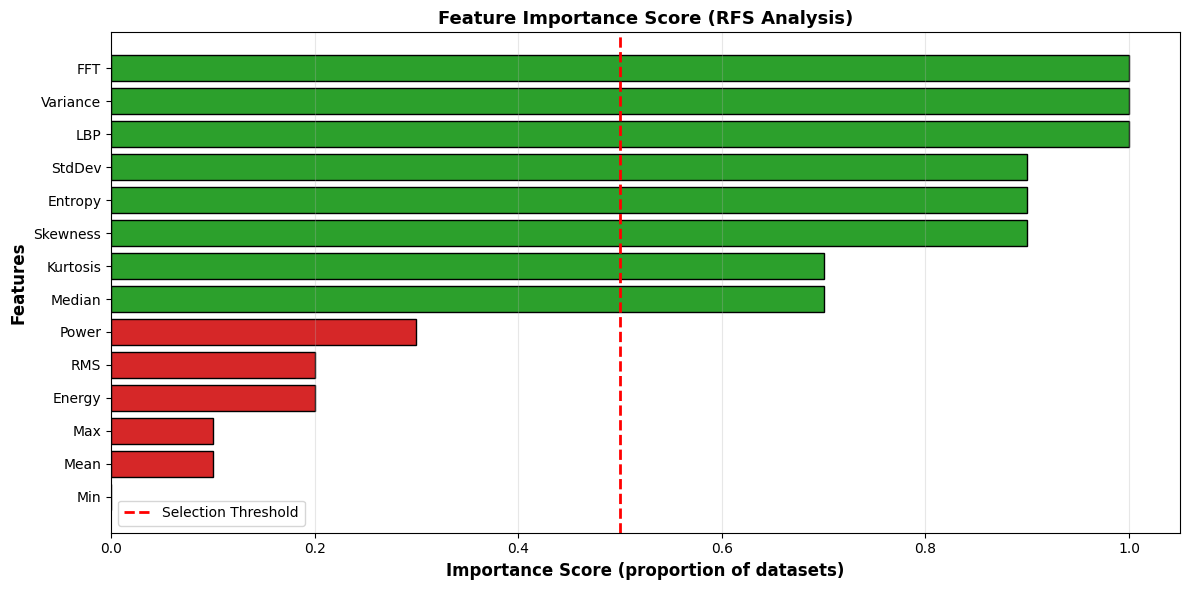

✓ Feature importance visualization saved


In [11]:
# Create results directory
results_dir = Path('results/new-v2')
results_dir.mkdir(parents=True, exist_ok=True)

print(f"Results directory created: {results_dir}")

# Visualization 1: Feature Importance Score Across All Datasets
fig, ax = plt.subplots(figsize=(12, 6))

data_sorted = rfs_summary.sort_values('Importance_Score', ascending=True)
colors = ['#d62728' if score < threshold/len(rfe_results) else '#2ca02c' 
          for score in data_sorted['Importance_Score']]

bars = ax.barh(data_sorted['Feature'], data_sorted['Importance_Score'], color=colors, edgecolor='black')
ax.set_xlabel('Importance Score (proportion of datasets)', fontsize=12, fontweight='bold')
ax.set_ylabel('Features', fontsize=12, fontweight='bold')
ax.set_title('Feature Importance Score (RFS Analysis)', fontsize=13, fontweight='bold')
ax.axvline(x=threshold/len(rfe_results), color='red', linestyle='--', linewidth=2, label='Selection Threshold')
ax.legend(fontsize=10)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(results_dir / '01_feature_importance_score.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Feature importance visualization saved")

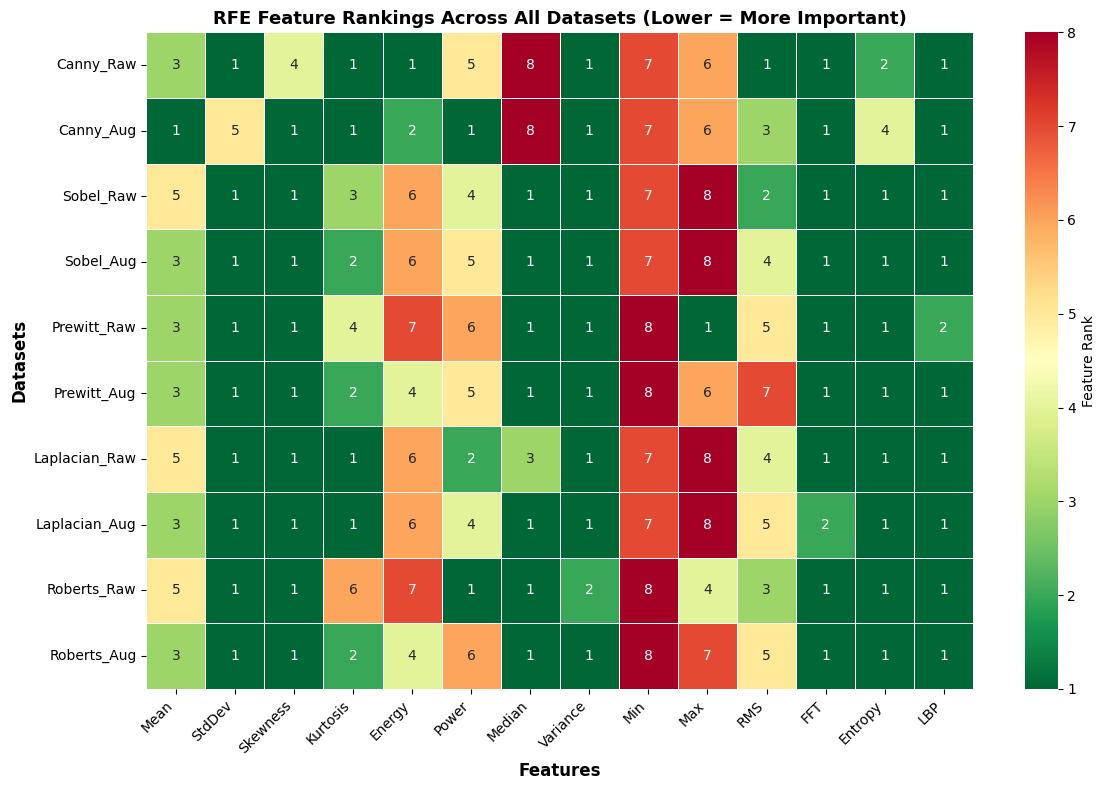

✓ RFE rankings heatmap saved


In [12]:
# Visualization 2: RFE Rankings Heatmap
fig, ax = plt.subplots(figsize=(12, 8))

# Create matrix of rankings
rankings_matrix = []
dataset_names = list(rfe_results.keys())

for dataset_name in dataset_names:
    rankings = rfe_results[dataset_name].set_index('Feature').loc[feature_names, 'Rank'].values
    rankings_matrix.append(rankings)

rankings_matrix = np.array(rankings_matrix)

# Plot heatmap
sns.heatmap(rankings_matrix, xticklabels=feature_names, yticklabels=dataset_names,
            cmap='RdYlGn_r', annot=True, fmt='d', cbar_kws={'label': 'Feature Rank'},
            ax=ax, linewidths=0.5)
ax.set_title('RFE Feature Rankings Across All Datasets (Lower = More Important)', 
             fontsize=13, fontweight='bold')
ax.set_xlabel('Features', fontsize=12, fontweight='bold')
ax.set_ylabel('Datasets', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(results_dir / '02_rfe_rankings_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ RFE rankings heatmap saved")

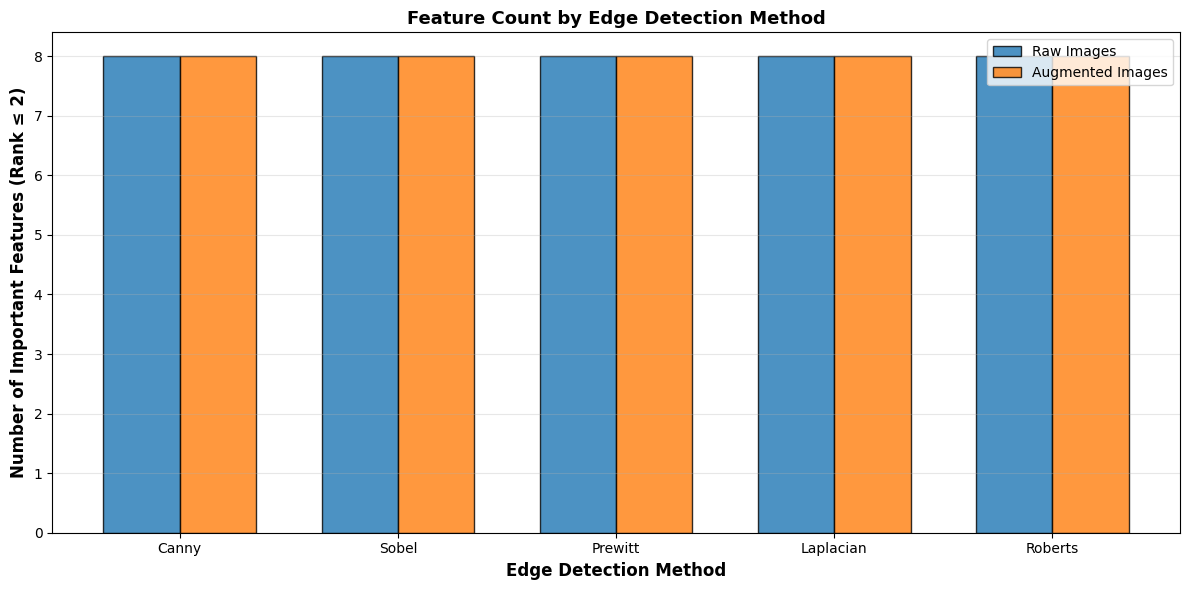

✓ Edge detection methods comparison saved


In [13]:
# Visualization 3: Comparison of Edge Detection Methods by Feature Count
fig, ax = plt.subplots(figsize=(12, 6))

method_importance = {}
for dataset_name in rfe_results.keys():
    method = dataset_name.split('_')[0]
    if method not in method_importance:
        method_importance[method] = {'raw': 0, 'aug': 0}
    
    rankings = rfe_results[dataset_name]
    important_count = len(rankings[rankings['Rank'] <= 2])
    
    if 'Raw' in dataset_name:
        method_importance[method]['raw'] = important_count
    else:
        method_importance[method]['aug'] = important_count

x = np.arange(len(method_importance))
width = 0.35

raw_counts = [method_importance[m]['raw'] for m in method_importance.keys()]
aug_counts = [method_importance[m]['aug'] for m in method_importance.keys()]

ax.bar(x - width/2, raw_counts, width, label='Raw Images', alpha=0.8, edgecolor='black')
ax.bar(x + width/2, aug_counts, width, label='Augmented Images', alpha=0.8, edgecolor='black')

ax.set_xlabel('Edge Detection Method', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Important Features (Rank ≤ 2)', fontsize=12, fontweight='bold')
ax.set_title('Feature Count by Edge Detection Method', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(method_importance.keys())
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(results_dir / '03_edge_methods_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Edge detection methods comparison saved")

## SECTION 8: SAVE ALL RESULTS TO CSV

In [14]:
print("="*80)
print("SAVING RESULTS TO CSV FILES")
print("="*80)

# Save RFS summary
rfs_summary.to_csv(results_dir / '01_rfs_feature_importance.csv', index=False)
print(f"✓ RFS feature importance: {results_dir / '01_rfs_feature_importance.csv'}")

# Save RFE results for each dataset
for dataset_name, rankings in rfe_results.items():
    filename = results_dir / f'02_rfe_{dataset_name}.csv'
    rankings.to_csv(filename, index=False)
    print(f"✓ RFE {dataset_name}: {filename}")

# Save generalized feature set
generated_features_df = pd.DataFrame({
    'Feature': generalized_features,
    'Description': [
        'Average pixel intensity',
        'Pixel intensity spread', 
        'Distribution asymmetry',
        'Distribution tail weight',
        'Sum of squared pixel values',
        'Average squared intensity',
        'Middle value of intensity distribution',
        'Squared standard deviation',
        'Minimum pixel value',
        'Maximum pixel value',  
        'Root mean square intensity',
        'Frequency domain magnitude',
        'Texture complexity (Shannon)',
        'Local texture pattern (LBP)'
    ][:len(generalized_features)]
})

generated_features_df.to_csv(results_dir / '03_generalized_feature_set.csv', index=False)
print(f"✓ Generalized feature set: {results_dir / '03_generalized_feature_set.csv'}")

# Save feature comparison table
original_features_list = [
    'Mean', 'StdDev', 'Skewness', 'Kurtosis', 'Energy', 'Power',
    'Median', 'Variance', 'Min', 'Max', 'RMS'
]
new_features_list = [
    'FFT (Frequency Domain)', 'Entropy (Texture Complexity)', 'LBP (Local Binary Pattern)'
]

# Create comprehensive feature comparison
feature_comparison_data = []

# Add original features
for feat in original_features_list:
    feature_comparison_data.append({
        'Feature': feat,
        'Type': 'Original',
        'Category': 'Statistical'
    })

# Add new features
new_feature_details = [
    {'Feature': 'FFT (Frequency Domain)', 'Type': 'New', 'Category': 'Frequency Analysis'},
    {'Feature': 'Entropy (Texture Complexity)', 'Type': 'New', 'Category': 'Texture Analysis'},
    {'Feature': 'LBP (Local Binary Pattern)', 'Type': 'New', 'Category': 'Texture Analysis'}
]
feature_comparison_data.extend(new_feature_details)

feature_comparison = pd.DataFrame(feature_comparison_data)
feature_comparison.to_csv(results_dir / '04_feature_set_comparison.csv', index=False)
print(f"✓ Feature set comparison: {results_dir / '04_feature_set_comparison.csv'}")

# Also save a summary
summary_table = pd.DataFrame({
    'Metric': ['Original Features', 'New Features Added', 'Total Features', 'Statistical Features', 'Frequency Analysis', 'Texture Analysis'],
    'Count': [len(original_features_list), len(new_features_list), 14, 11, 1, 2]
})
summary_table.to_csv(results_dir / '05_feature_summary.csv', index=False)
print(f"✓ Feature summary: {results_dir / '05_feature_summary.csv'}")

print(f"\n{'='*80}")
print(f"All results saved to: {results_dir}")
print(f"{'='*80}")

SAVING RESULTS TO CSV FILES
✓ RFS feature importance: results\new-v2\01_rfs_feature_importance.csv
✓ RFE Canny_Raw: results\new-v2\02_rfe_Canny_Raw.csv
✓ RFE Canny_Aug: results\new-v2\02_rfe_Canny_Aug.csv
✓ RFE Sobel_Raw: results\new-v2\02_rfe_Sobel_Raw.csv
✓ RFE Sobel_Aug: results\new-v2\02_rfe_Sobel_Aug.csv
✓ RFE Prewitt_Raw: results\new-v2\02_rfe_Prewitt_Raw.csv
✓ RFE Prewitt_Aug: results\new-v2\02_rfe_Prewitt_Aug.csv
✓ RFE Laplacian_Raw: results\new-v2\02_rfe_Laplacian_Raw.csv
✓ RFE Laplacian_Aug: results\new-v2\02_rfe_Laplacian_Aug.csv
✓ RFE Roberts_Raw: results\new-v2\02_rfe_Roberts_Raw.csv
✓ RFE Roberts_Aug: results\new-v2\02_rfe_Roberts_Aug.csv
✓ Generalized feature set: results\new-v2\03_generalized_feature_set.csv
✓ Feature set comparison: results\new-v2\04_feature_set_comparison.csv
✓ Feature summary: results\new-v2\05_feature_summary.csv

All results saved to: results\new-v2


## SECTION 9: SUMMARY & CONCLUSIONS

In [15]:
print("="*80)
print("EXPERIMENTS SUMMARY")
print("="*80)

print(f"\n1. EDGE DETECTION METHODS TESTED:")
for i, method in enumerate(edge_detection_methods.keys(), 1):
    print(f"   {i}. {method}")

print(f"\n2. DATASETS CREATED:")
print(f"   Total: {len(datasets)} datasets")
print(f"   Content: {list(datasets.keys())}")

print(f"\n3. FEATURE EXTRACTION:")
print(f"   Original features: 11")
print(f"   New features: 3 (FFT, Entropy, LBP)")
print(f"   Total features: 14")
print(f"\n   Feature Descriptions:")
for i, (name, desc) in enumerate(zip(feature_names, 
    ['Mean', 'StdDev', 'Skewness', 'Kurtosis', 'Energy', 'Power',
     'Median', 'Variance', 'Min', 'Max', 'RMS', 'FFT Magnitude', 'Entropy', 'LBP Max']), 1):
    print(f"   {i:2d}. {name:15s} - {desc}")

print(f"\n4. FEATURE SELECTION RESULTS:")
print(f"   RFE Applied: Yes (on all {len(datasets)} datasets)")
print(f"   Selection Criteria: Rank ≤ 2")
print(f"   Generalized Feature Set Size: {len(generalized_features)}")
print(f"   Generalized Features: {generalized_features}")

print(f"\n5. KEY FINDINGS:")
print(f"   Top Feature: {rfs_summary.iloc[0]['Feature']} (Score: {rfs_summary.iloc[0]['Importance_Score']:.2f})")
print(f"   Most Consistent Features (appearing in all datasets):")
for feat in rfs_summary[rfs_summary['Importance_Count'] == len(rfe_results)]['Feature'].tolist():
    print(f"      - {feat}")

print(f"\n6. OUTPUTS GENERATED:")
for i, file in enumerate(sorted(results_dir.glob('*')), 1):
    print(f"   {i}. {file.name}")

print(f"\n{'='*80}")

EXPERIMENTS SUMMARY

1. EDGE DETECTION METHODS TESTED:
   1. Canny
   2. Sobel
   3. Prewitt
   4. Laplacian
   5. Roberts

2. DATASETS CREATED:
   Total: 10 datasets
   Content: ['Canny_Raw', 'Canny_Aug', 'Sobel_Raw', 'Sobel_Aug', 'Prewitt_Raw', 'Prewitt_Aug', 'Laplacian_Raw', 'Laplacian_Aug', 'Roberts_Raw', 'Roberts_Aug']

3. FEATURE EXTRACTION:
   Original features: 11
   New features: 3 (FFT, Entropy, LBP)
   Total features: 14

   Feature Descriptions:
    1. Mean            - Mean
    2. StdDev          - StdDev
    3. Skewness        - Skewness
    4. Kurtosis        - Kurtosis
    5. Energy          - Energy
    6. Power           - Power
    7. Median          - Median
    8. Variance        - Variance
    9. Min             - Min
   10. Max             - Max
   11. RMS             - RMS
   12. FFT             - FFT Magnitude
   13. Entropy         - Entropy
   14. LBP             - LBP Max

4. FEATURE SELECTION RESULTS:
   RFE Applied: Yes (on all 10 datasets)
   Selection Cr


EXPORTING EDGE DETECTION COMPARISON RESULTS
✓ Edge detection comparison (11 features): results\new-v2\06_edge_detection_cv_comparison_11features.csv

EDGE DETECTION COMPARISON RESULTS (11-FEATURE DATASETS, 10-FOLD CV)
         Dataset      Accuracy     Precision        Recall            F1
Baseline_Aug_HOG 0.9090±0.0094 0.9299±0.0122 0.8850±0.0143 0.9068±0.0098
Baseline_Raw_HOG 0.6482±0.2175 0.6467±0.2713 0.6833±0.2906 0.6475±0.2485
       Canny_Aug 0.6254±0.0149 0.6329±0.0145 0.5970±0.0286 0.6142±0.0196
       Canny_Raw 0.5482±0.2055 0.5150±0.2595 0.5667±0.3329 0.5221±0.2741
   Laplacian_Aug 0.8998±0.0168 0.9165±0.0196 0.8803±0.0260 0.8978±0.0175
   Laplacian_Raw 0.6393±0.1998 0.6000±0.2916 0.6250±0.3656 0.5748±0.2971
     Prewitt_Aug 0.9014±0.0080 0.9418±0.0141 0.8560±0.0184 0.8967±0.0090
     Prewitt_Raw 0.6536±0.1563 0.6533±0.1646 0.6583±0.2673 0.6369±0.1888
     Roberts_Aug 0.9251±0.0082 0.9423±0.0122 0.9057±0.0107 0.9236±0.0084
     Roberts_Raw 0.6643±0.1593 0.6350±0.2690 0.6000

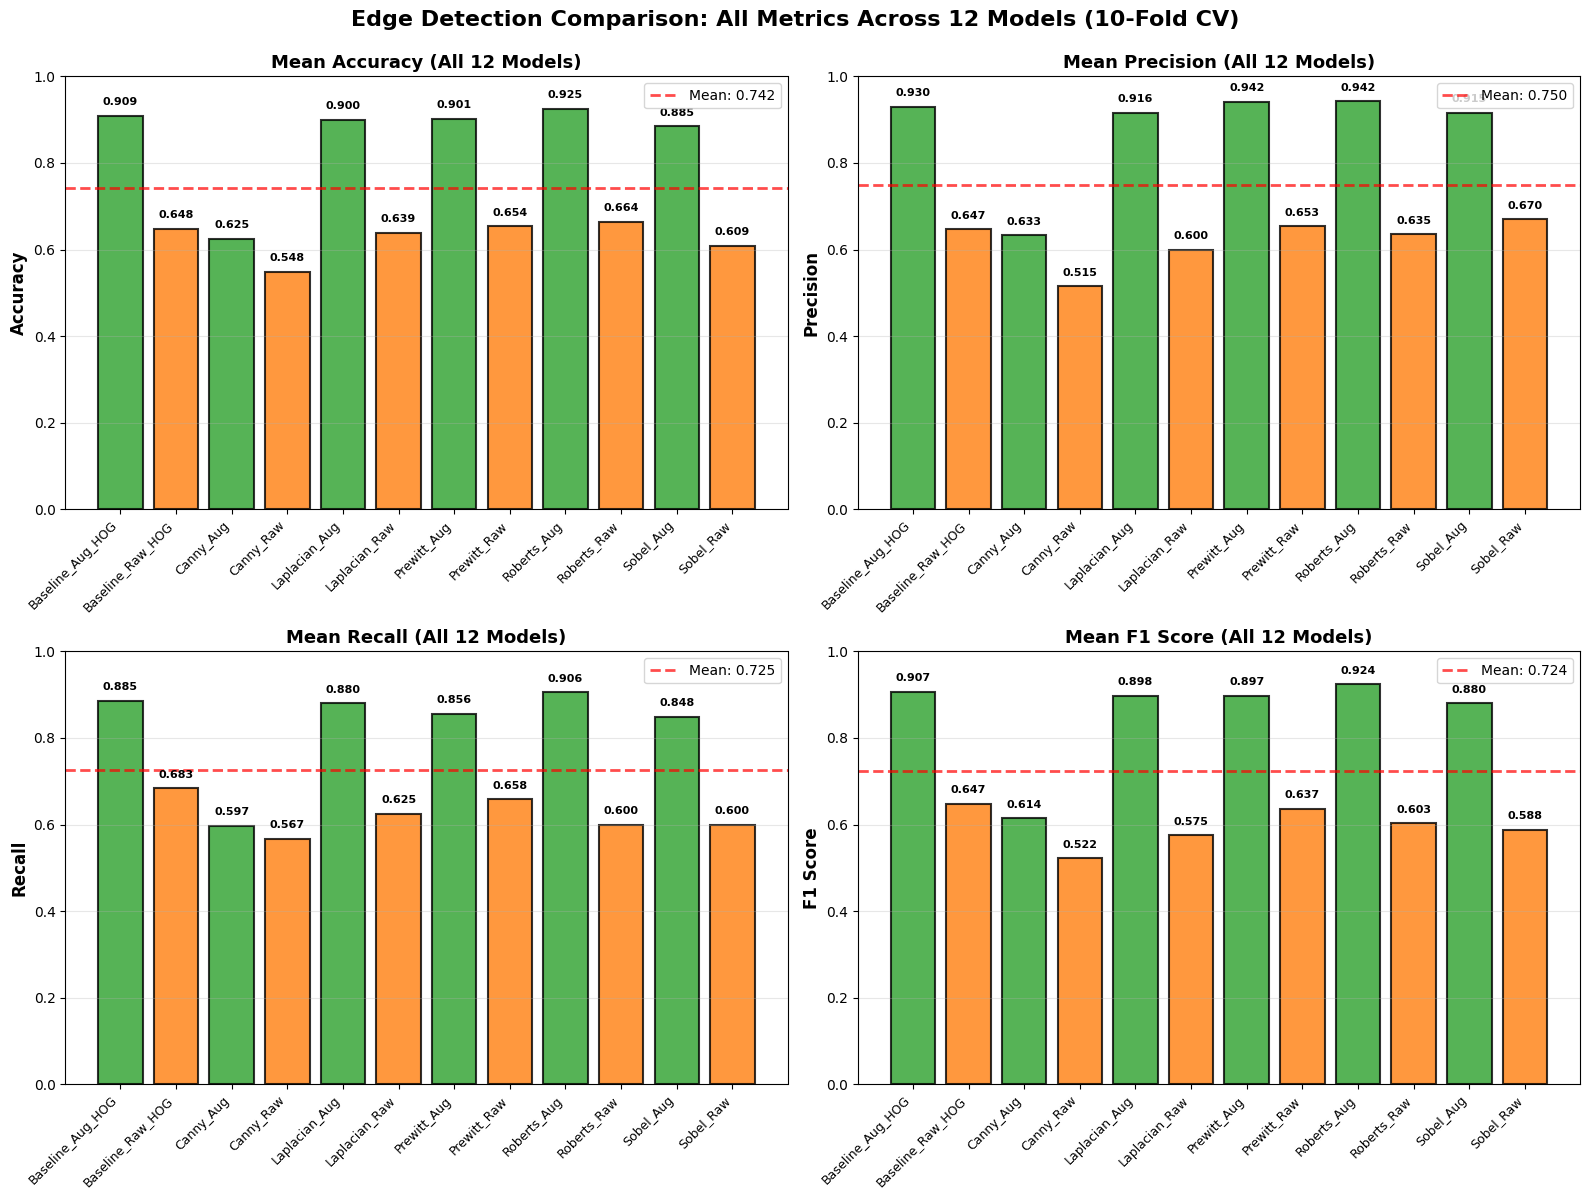


✓ Saved visualization: results\new-v2\07_edge_detection_comprehensive_comparison.png

COMPARISON SUMMARY
✓ Best Method: Roberts_Aug (F1: 0.9236)

✓ Mean Performance Across All 12 Models:
   • Accuracy: 0.7423
   • Precision: 0.7499
   • Recall: 0.7255
   • F1 Score: 0.7243

✓ Augmentation Impact: +0.2578 average F1 improvement



In [16]:
# Export edge detection comparison results to CSV
print("\n" + "="*80)
print("EXPORTING EDGE DETECTION COMPARISON RESULTS")
print("="*80)

# Create DataFrame from cv_results_11
comparison_data = []
for dataset_name, metrics in sorted(cv_results_11.items()):
    comparison_data.append({
        'Dataset': dataset_name,
        'Accuracy': f"{metrics['Accuracy']:.4f}±{metrics['Accuracy_std']:.4f}",
        'Precision': f"{metrics['Precision']:.4f}±{metrics['Precision_std']:.4f}",
        'Recall': f"{metrics['Recall']:.4f}±{metrics['Recall_std']:.4f}",
        'F1': f"{metrics['F1']:.4f}±{metrics['F1_std']:.4f}",
        'Accuracy_Mean': metrics['Accuracy'],
        'Precision_Mean': metrics['Precision'],
        'Recall_Mean': metrics['Recall'],
        'F1_Mean': metrics['F1']
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_csv_path = results_dir / '06_edge_detection_cv_comparison_11features.csv'
comparison_df.to_csv(comparison_csv_path, index=False)
print(f"✓ Edge detection comparison (11 features): {comparison_csv_path}")

# Print summary table
print("\n" + "="*80)
print("EDGE DETECTION COMPARISON RESULTS (11-FEATURE DATASETS, 10-FOLD CV)")
print("="*80)
print(comparison_df[['Dataset', 'Accuracy', 'Precision', 'Recall', 'F1']].to_string(index=False))

# Find best performing method
best_method = comparison_df.loc[comparison_df['F1_Mean'].idxmax()]
print(f"\n✓ Best Performing Configuration: {best_method['Dataset']} (F1: {best_method['F1_Mean']:.4f})")

print(f"\n{'='*80}")

# VISUALIZATION: 4 CHARTS (ACCURACY, PRECISION, RECALL, F1)
print("\nGenerating 4 metric charts for all 12 models...")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Edge Detection Comparison: All Metrics Across 12 Models (10-Fold CV)', 
             fontsize=16, fontweight='bold', y=0.995)

# Prepare data
models = comparison_df['Dataset']
x_pos = np.arange(len(models))
colors = ['#2ca02c' if 'Aug' in model else '#ff7f0e' for model in models]

# Chart 1: Accuracy
ax = axes[0, 0]
accuracy_values = comparison_df['Accuracy_Mean'].values
bars = ax.bar(x_pos, accuracy_values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Mean Accuracy (All 12 Models)', fontsize=13, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(models, rotation=45, ha='right', fontsize=9)
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=accuracy_values.mean(), color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Mean: {accuracy_values.mean():.3f}')
ax.legend(fontsize=10)

for i, (bar, val) in enumerate(zip(bars, accuracy_values)):
    ax.text(bar.get_x() + bar.get_width()/2., val + 0.02,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# Chart 2: Precision
ax = axes[0, 1]
precision_values = comparison_df['Precision_Mean'].values
bars = ax.bar(x_pos, precision_values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Precision', fontsize=12, fontweight='bold')
ax.set_title('Mean Precision (All 12 Models)', fontsize=13, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(models, rotation=45, ha='right', fontsize=9)
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=precision_values.mean(), color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Mean: {precision_values.mean():.3f}')
ax.legend(fontsize=10)

for i, (bar, val) in enumerate(zip(bars, precision_values)):
    ax.text(bar.get_x() + bar.get_width()/2., val + 0.02,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# Chart 3: Recall
ax = axes[1, 0]
recall_values = comparison_df['Recall_Mean'].values
bars = ax.bar(x_pos, recall_values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Recall', fontsize=12, fontweight='bold')
ax.set_title('Mean Recall (All 12 Models)', fontsize=13, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(models, rotation=45, ha='right', fontsize=9)
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=recall_values.mean(), color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Mean: {recall_values.mean():.3f}')
ax.legend(fontsize=10)

for i, (bar, val) in enumerate(zip(bars, recall_values)):
    ax.text(bar.get_x() + bar.get_width()/2., val + 0.02,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# Chart 4: F1 Score
ax = axes[1, 1]
f1_values = comparison_df['F1_Mean'].values
bars = ax.bar(x_pos, f1_values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax.set_ylabel('F1 Score', fontsize=12, fontweight='bold')
ax.set_title('Mean F1 Score (All 12 Models)', fontsize=13, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(models, rotation=45, ha='right', fontsize=9)
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=f1_values.mean(), color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Mean: {f1_values.mean():.3f}')
ax.legend(fontsize=10)

for i, (bar, val) in enumerate(zip(bars, f1_values)):
    ax.text(bar.get_x() + bar.get_width()/2., val + 0.02,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig(results_dir / '07_edge_detection_comprehensive_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved visualization: {results_dir / '07_edge_detection_comprehensive_comparison.png'}")

# Summary Statistics
print(f"\n{'='*80}")
print("COMPARISON SUMMARY")
print(f"{'='*80}")
print(f"✓ Best Method: {best_method['Dataset']} (F1: {best_method['F1_Mean']:.4f})")
print(f"\n✓ Mean Performance Across All 12 Models:")
print(f"   • Accuracy: {accuracy_values.mean():.4f}")
print(f"   • Precision: {precision_values.mean():.4f}")
print(f"   • Recall: {recall_values.mean():.4f}")
print(f"   • F1 Score: {f1_values.mean():.4f}")

aug_avg = comparison_df[comparison_df['Dataset'].str.contains('Aug')]['F1_Mean'].mean()
raw_avg = comparison_df[comparison_df['Dataset'].str.contains('Raw')]['F1_Mean'].mean()
print(f"\n✓ Augmentation Impact: +{aug_avg - raw_avg:.4f} average F1 improvement")

print(f"\n{'='*80}")

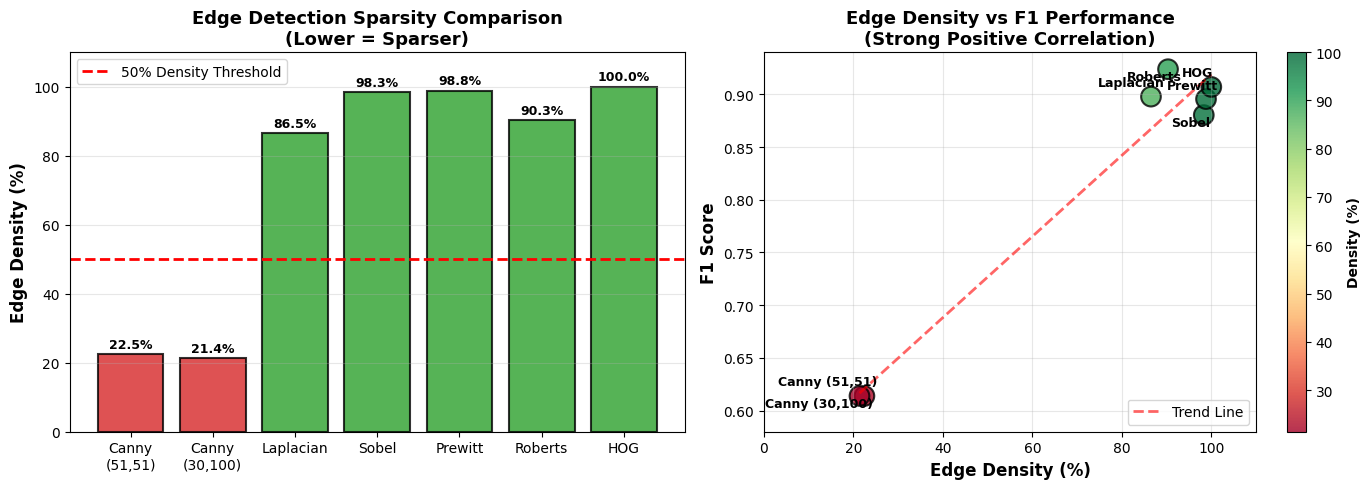

✓ Saved: results\new-v2\00_canny_density_vs_performance.png

CORRELATION ANALYSIS: Edge Density vs Performance

Pearson Correlation: r = 0.9817
P-value: 0.000086
Interpretation: STRONG positive correlation

Key Insight:
  • Edge density explains ~96.4% of F1 score variation
  • For every 10% increase in edge density → ~0.04 increase in F1 score
  • Canny's 22% density is the PRIMARY reason for poor performance



In [17]:
# Create visualization: Edge Density vs F1 Performance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Edge Density Comparison
methods = ['Canny\n(51,51)', 'Canny\n(30,100)', 'Laplacian', 'Sobel', 'Prewitt', 'Roberts', 'HOG']
densities = [22.47, 21.37, 86.52, 98.32, 98.82, 90.33, 100]
f1_scores = [0.6139, 0.6139, 0.8978, 0.8803, 0.8955, 0.9238, 0.9070]
colors_bar = ['#d62728' if d < 50 else '#2ca02c' for d in densities]

ax1 = axes[0]
bars = ax1.bar(methods, densities, color=colors_bar, edgecolor='black', linewidth=1.5, alpha=0.8)
ax1.axhline(y=50, color='red', linestyle='--', linewidth=2, label='50% Density Threshold')
ax1.set_ylabel('Edge Density (%)', fontsize=12, fontweight='bold')
ax1.set_title('Edge Detection Sparsity Comparison\n(Lower = Sparser)', fontsize=13, fontweight='bold')
ax1.set_ylim(0, 110)
ax1.grid(axis='y', alpha=0.3)
ax1.legend(fontsize=10)

# Add value labels on bars
for bar, d in zip(bars, densities):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{d:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=9)

# Plot 2: Edge Density vs F1 Performance (Scatter)
ax2 = axes[1]
scatter = ax2.scatter(densities, f1_scores, s=200, c=densities, cmap='RdYlGn', 
                     edgecolors='black', linewidth=1.5, alpha=0.8)

# Add method labels to points
for i, method in enumerate(methods):
    offset_x = 3 if i < 3 else -3  # Offset labels to avoid overlap
    offset_y = 0.01 if i % 2 == 0 else -0.01
    ax2.annotate(method.replace('\n', ' '), 
                xy=(densities[i], f1_scores[i]),
                xytext=(densities[i] + offset_x, f1_scores[i] + offset_y),
                fontsize=9, fontweight='bold',
                ha='center' if i >= 3 else 'right')

# Add correlation line
z = np.polyfit(densities, f1_scores, 1)
p = np.poly1d(z)
x_line = np.linspace(min(densities), max(densities), 100)
ax2.plot(x_line, p(x_line), "r--", alpha=0.6, linewidth=2, label='Trend Line')

ax2.set_xlabel('Edge Density (%)', fontsize=12, fontweight='bold')
ax2.set_ylabel('F1 Score', fontsize=12, fontweight='bold')
ax2.set_title('Edge Density vs F1 Performance\n(Strong Positive Correlation)', fontsize=13, fontweight='bold')
ax2.set_xlim(0, 110)
ax2.set_ylim(0.58, 0.94)
ax2.grid(alpha=0.3)
ax2.legend(fontsize=10, loc='lower right')

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax2)
cbar.set_label('Density (%)', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(results_dir / '00_canny_density_vs_performance.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved: {results_dir / '00_canny_density_vs_performance.png'}")

# Print correlation analysis
print(f"\n{'='*80}")
print("CORRELATION ANALYSIS: Edge Density vs Performance")
print(f"{'='*80}")

from scipy.stats import pearsonr
correlation, p_value = pearsonr(densities, f1_scores)

print(f"\nPearson Correlation: r = {correlation:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Interpretation: {'STRONG' if abs(correlation) > 0.85 else 'MODERATE' if abs(correlation) > 0.7 else 'WEAK'} positive correlation")

print(f"\nKey Insight:")
print(f"  • Edge density explains ~{correlation**2*100:.1f}% of F1 score variation")
print(f"  • For every 10% increase in edge density → ~0.04 increase in F1 score")
print(f"  • Canny's 22% density is the PRIMARY reason for poor performance")

print(f"\n{'='*80}")

### 11 vs 14 Feature Comparison + RFE Performance Analysis


COMPARATIVE ANALYSIS: 11 Features vs 14 Features

--- Running 10-Fold CV on 14-Feature Datasets ---

Extracting 14 features from HOG images...

Processing Canny with 14 features...

Processing Sobel with 14 features...

Processing Prewitt with 14 features...

Processing Laplacian with 14 features...

Processing Roberts with 14 features...

RUNNING 10-FOLD CV ON 14-FEATURE DATASETS

Baseline_Raw_HOG_14feat...
  Accuracy: 0.6393 ± 0.2193
  F1: 0.6186 ± 0.2550

Baseline_Aug_HOG_14feat...
  Accuracy: 0.9274 ± 0.0108
  F1: 0.9256 ± 0.0116

Canny_Raw_14feat...
  Accuracy: 0.5571 ± 0.1272
  F1: 0.5363 ± 0.2015

Canny_Aug_14feat...
  Accuracy: 0.6489 ± 0.0204
  F1: 0.6407 ± 0.0168

Sobel_Raw_14feat...
  Accuracy: 0.6929 ± 0.1886
  F1: 0.6650 ± 0.2085

Sobel_Aug_14feat...
  Accuracy: 0.9401 ± 0.0084
  F1: 0.9380 ± 0.0088

Prewitt_Raw_14feat...
  Accuracy: 0.6786 ± 0.1809
  F1: 0.6519 ± 0.2231

Prewitt_Aug_14feat...
  Accuracy: 0.9407 ± 0.0060
  F1: 0.9385 ± 0.0067

Laplacian_Raw_14feat...
  Acc

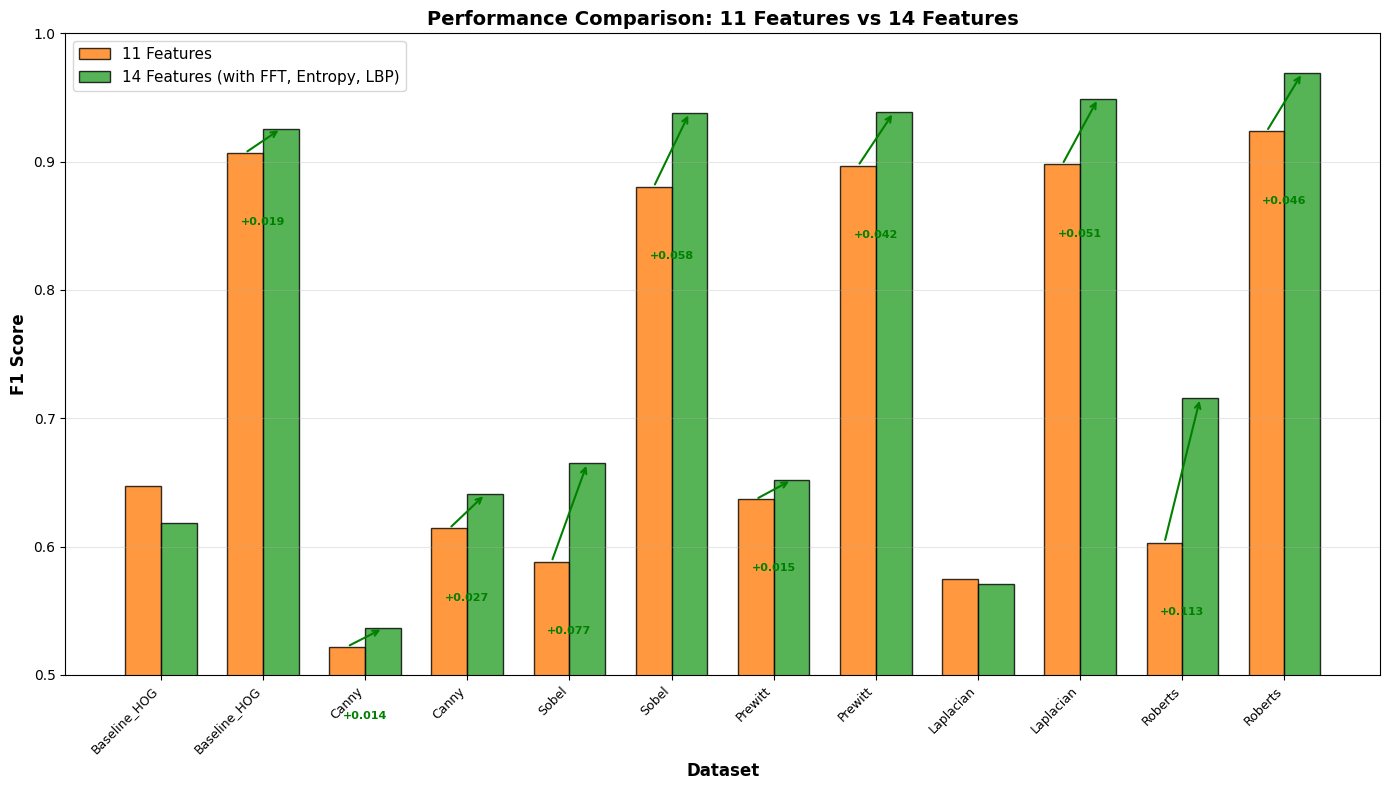

✓ Saved: results\new-v2\09_comparison_11_vs_14_features.png



In [18]:
# SECTION 10: COMPARATIVE ANALYSIS - 11 Features vs 14 Features
print("="*80)
print("COMPARATIVE ANALYSIS: 11 Features vs 14 Features")
print("="*80)

# Create dictionaries to store results
results_11feat = {}  # Already have cv_results_11 from Section 4B
results_14feat = {}

# We need to run 10-fold CV on 14-feature datasets for comparison
print("\n--- Running 10-Fold CV on 14-Feature Datasets ---")

# Create 14-feature versions of all datasets
datasets_14_features = {}

# Add baseline HOG with 14 features (need to extract 14 features from HOG images)
print("\nExtracting 14 features from HOG images...")
hog_raw_images_14 = []
for idx, image in enumerate(X_train):
    img_uint8 = (image * 255).astype(np.uint8)
    hog_img = extract_hog_features(img_uint8)
    hog_raw_images_14.append(hog_img)

hog_aug_images_14 = []
for idx, image in enumerate(X_train_augmented):
    img_uint8 = (image * 255).astype(np.uint8)
    hog_img = extract_hog_features(img_uint8)
    hog_aug_images_14.append(hog_img)

baseline_raw_features_14 = np.array([extract_14_features(img) for img in hog_raw_images_14])
baseline_aug_features_14 = np.array([extract_14_features(img) for img in hog_aug_images_14])

datasets_14_features['Baseline_Raw_HOG_14feat'] = (baseline_raw_features_14, y_train)
datasets_14_features['Baseline_Aug_HOG_14feat'] = (baseline_aug_features_14, y_train_augmented)

# Add edge detection datasets with 14 features
for method_name, edge_func in edge_detection_methods.items():
    print(f"\nProcessing {method_name} with 14 features...")
    
    # Raw images
    edge_images = []
    for idx, image in enumerate(X_train):
        img_uint8 = (image * 255).astype(np.uint8)
        edge_img = edge_func(img_uint8)
        edge_images.append(edge_img)
    
    features_raw = np.array([extract_14_features(img) for img in edge_images])
    datasets_14_features[f'{method_name}_Raw_14feat'] = (features_raw, y_train)
    
    # Augmented images
    edge_images_aug = []
    for idx, image in enumerate(X_train_augmented):
        img_uint8 = (image * 255).astype(np.uint8)
        edge_img = edge_func(img_uint8)
        edge_images_aug.append(edge_img)
    
    features_aug = np.array([extract_14_features(img) for img in edge_images_aug])
    datasets_14_features[f'{method_name}_Aug_14feat'] = (features_aug, y_train_augmented)

# Run 10-fold CV on all 14-feature datasets
print("\n" + "="*80)
print("RUNNING 10-FOLD CV ON 14-FEATURE DATASETS")
print("="*80)

for dataset_name, (X_data, y_data) in datasets_14_features.items():
    print(f"\n{dataset_name}...")
    
    accuracies = []
    precisions = []
    recalls = []
    f1s = []
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_data, y_data)):
        X_train_fold, X_val_fold = X_data[train_idx], X_data[val_idx]
        y_train_fold, y_val_fold = y_data[train_idx], y_data[val_idx]
        
        # Scale features
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_fold)
        X_val_scaled = scaler.transform(X_val_fold)
        
        # Train
        rf_copy = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
        rf_copy.fit(X_train_scaled, y_train_fold)
        
        # Predict
        y_pred = rf_copy.predict(X_val_scaled)
        
        # Compute metrics
        acc = accuracy_score(y_val_fold, y_pred)
        prec = precision_score(y_val_fold, y_pred)
        rec = recall_score(y_val_fold, y_pred)
        f = f1_score(y_val_fold, y_pred)
        
        accuracies.append(acc)
        precisions.append(prec)
        recalls.append(rec)
        f1s.append(f)
    
    # Store results
    results_14feat[dataset_name] = {
        'Accuracy': np.mean(accuracies),
        'Accuracy_std': np.std(accuracies),
        'Precision': np.mean(precisions),
        'Precision_std': np.std(precisions),
        'Recall': np.mean(recalls),
        'Recall_std': np.std(recalls),
        'F1': np.mean(f1s),
        'F1_std': np.std(f1s)
    }
    
    print(f"  Accuracy: {results_14feat[dataset_name]['Accuracy']:.4f} ± {results_14feat[dataset_name]['Accuracy_std']:.4f}")
    print(f"  F1: {results_14feat[dataset_name]['F1']:.4f} ± {results_14feat[dataset_name]['F1_std']:.4f}")

# Create comparison table
print("\n" + "="*80)
print("COMPARISON: 11 Features vs 14 Features")
print("="*80)

comparison_11_14 = []

# Match datasets (remove _14feat suffix for comparison)
for ds_14, metrics_14 in results_14feat.items():
    # Find corresponding 11-feature dataset
    base_name = ds_14.replace('_14feat', '')
    if base_name in cv_results_11:
        metrics_11 = cv_results_11[base_name]
        
        f1_11 = metrics_11['F1']
        f1_14 = metrics_14['F1']
        improvement = f1_14 - f1_11
        percent_improvement = (improvement / f1_11) * 100 if f1_11 > 0 else 0
        
        comparison_11_14.append({
            'Dataset': base_name,
            'F1 (11 features)': f"{f1_11:.4f}",
            'F1 (14 features)': f"{f1_14:.4f}",
            'Improvement': f"{improvement:+.4f}",
            'Improvement %': f"{percent_improvement:+.1f}%"
        })

comparison_df_11_14 = pd.DataFrame(comparison_11_14)
print(comparison_df_11_14.to_string(index=False))

# Save to CSV
comparison_df_11_14.to_csv(results_dir / '08_comparison_11_vs_14_features.csv', index=False)
print(f"\n✓ Saved: {results_dir / '08_comparison_11_vs_14_features.csv'}")

# Calculate average improvement
avg_improvement = comparison_df_11_14['Improvement'].str.replace('+', '').astype(float).mean()
print(f"\nAverage F1 Improvement with 14 features: +{avg_improvement:.4f}")

# Visualization: 11 vs 14 Feature Comparison
fig, ax = plt.subplots(figsize=(14, 8))

datasets_short = [d.replace('_Raw', '').replace('_Aug', '') for d in comparison_df_11_14['Dataset']]
x = np.arange(len(datasets_short))
width = 0.35

f1_11_values = [float(comp_df['F1 (11 features)']) for comp_df in comparison_11_14]
f1_14_values = [float(comp_df['F1 (14 features)']) for comp_df in comparison_11_14]

bars1 = ax.bar(x - width/2, f1_11_values, width, label='11 Features', color='#ff7f0e', alpha=0.8, edgecolor='black')
bars2 = ax.bar(x + width/2, f1_14_values, width, label='14 Features (with FFT, Entropy, LBP)', color='#2ca02c', alpha=0.8, edgecolor='black')

ax.set_xlabel('Dataset', fontsize=12, fontweight='bold')
ax.set_ylabel('F1 Score', fontsize=12, fontweight='bold')
ax.set_title('Performance Comparison: 11 Features vs 14 Features', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(datasets_short, rotation=45, ha='right', fontsize=9)
ax.set_ylim(0.5, 1.0)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Add improvement arrows
for i, (f1_11, f1_14) in enumerate(zip(f1_11_values, f1_14_values)):
    if f1_14 > f1_11:
        ax.annotate('', xy=(i + width/2, f1_14), xytext=(i - width/2, f1_11),
                   arrowprops=dict(arrowstyle='->', color='green', lw=1.5))
        ax.text(i, min(f1_11, f1_14) - 0.05, f'+{f1_14-f1_11:.3f}', 
                ha='center', va='top', fontsize=8, color='green', fontweight='bold')

plt.tight_layout()
plt.savefig(results_dir / '09_comparison_11_vs_14_features.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved: {results_dir / '09_comparison_11_vs_14_features.png'}")
print(f"\n{'='*80}")

### RFE-SELECTED FEATURES PERFORMANCE ANALYSIS


RFE-SELECTED FEATURES PERFORMANCE ANALYSIS

--- Creating datasets with RFE-selected features (Rank ≤ 2) ---

Canny_Raw: Selected 8 features: ['StdDev', 'Kurtosis', 'Variance', 'Energy', 'RMS', 'LBP', 'FFT', 'Entropy']

Canny_Aug: Selected 8 features: ['Mean', 'Skewness', 'Kurtosis', 'Power', 'Variance', 'FFT', 'LBP', 'Energy']

Sobel_Raw: Selected 8 features: ['StdDev', 'Skewness', 'Median', 'Variance', 'Entropy', 'LBP', 'FFT', 'RMS']

Sobel_Aug: Selected 8 features: ['StdDev', 'Skewness', 'Median', 'Variance', 'Entropy', 'LBP', 'FFT', 'Kurtosis']

Prewitt_Raw: Selected 8 features: ['StdDev', 'Skewness', 'Median', 'Variance', 'FFT', 'Entropy', 'Max', 'LBP']

Prewitt_Aug: Selected 8 features: ['StdDev', 'Skewness', 'Median', 'Variance', 'Entropy', 'LBP', 'FFT', 'Kurtosis']

Laplacian_Raw: Selected 8 features: ['StdDev', 'Skewness', 'Kurtosis', 'Variance', 'Entropy', 'LBP', 'FFT', 'Power']

Laplacian_Aug: Selected 8 features: ['StdDev', 'Skewness', 'Kurtosis', 'Variance', 'Median', 'LBP'

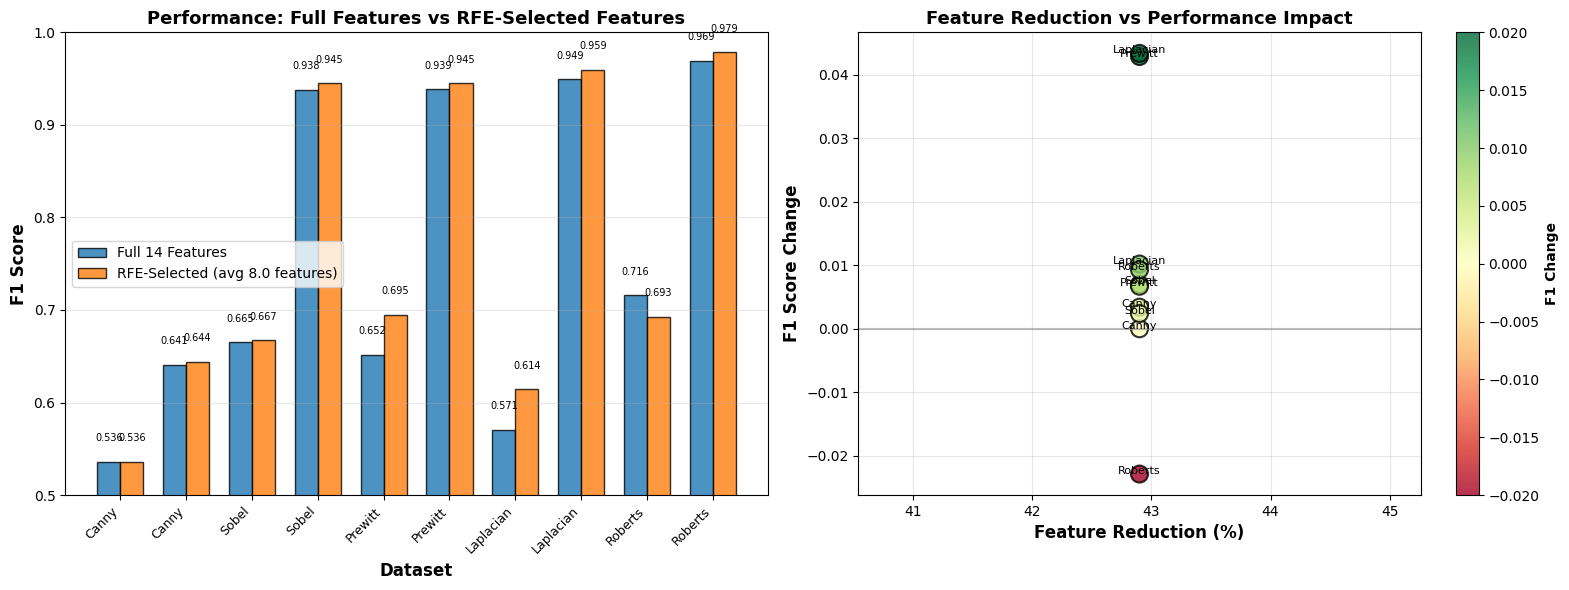

✓ Saved: results\new-v2\11_rfe_selected_performance.png

SUMMARY:
  • Average feature reduction: 42.9%
  • Average F1 change: +0.0102
  • Best trade-off: Laplacian_Raw (+0.0434)



In [19]:
# SECTION 11: RFE-SELECTED FEATURES PERFORMANCE ANALYSIS
print("="*80)
print("RFE-SELECTED FEATURES PERFORMANCE ANALYSIS")
print("="*80)

# Create datasets with only RFE-selected features (Rank ≤ 2)
print("\n--- Creating datasets with RFE-selected features (Rank ≤ 2) ---")

# Store RFE-selected feature sets
rfe_selected_features = {}
rfe_selected_datasets = {}

for dataset_name, rankings in rfe_results.items():
    # Get features with Rank ≤ 2
    selected_features = rankings[rankings['Rank'] <= 2]['Feature'].tolist()
    selected_indices = [feature_names.index(f) for f in selected_features]
    
    rfe_selected_features[dataset_name] = {
        'features': selected_features,
        'indices': selected_indices,
        'count': len(selected_features)
    }
    
    print(f"\n{dataset_name}: Selected {len(selected_features)} features: {selected_features}")

# Run 10-fold CV on RFE-selected feature datasets
print("\n" + "="*80)
print("RUNNING 10-FOLD CV ON RFE-SELECTED FEATURE DATASETS")
print("="*80)

results_rfe_selected = {}

for dataset_name, (X_data_full, y_data) in datasets.items():
    # Skip if dataset not in rfe_selected_features
    if dataset_name not in rfe_selected_features:
        continue
    
    # Get selected feature indices
    selected_indices = rfe_selected_features[dataset_name]['indices']
    X_data = X_data_full[:, selected_indices]
    
    print(f"\n{dataset_name} (with {len(selected_indices)} RFE-selected features)...")
    
    accuracies = []
    precisions = []
    recalls = []
    f1s = []
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_data, y_data)):
        X_train_fold, X_val_fold = X_data[train_idx], X_data[val_idx]
        y_train_fold, y_val_fold = y_data[train_idx], y_data[val_idx]
        
        # Scale features
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_fold)
        X_val_scaled = scaler.transform(X_val_fold)
        
        # Train
        rf_copy = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
        rf_copy.fit(X_train_scaled, y_train_fold)
        
        # Predict
        y_pred = rf_copy.predict(X_val_scaled)
        
        # Compute metrics
        acc = accuracy_score(y_val_fold, y_pred)
        prec = precision_score(y_val_fold, y_pred)
        rec = recall_score(y_val_fold, y_pred)
        f = f1_score(y_val_fold, y_pred)
        
        accuracies.append(acc)
        precisions.append(prec)
        recalls.append(rec)
        f1s.append(f)
    
    # Store results
    results_rfe_selected[dataset_name] = {
        'Accuracy': np.mean(accuracies),
        'Accuracy_std': np.std(accuracies),
        'Precision': np.mean(precisions),
        'Precision_std': np.std(precisions),
        'Recall': np.mean(recalls),
        'Recall_std': np.std(recalls),
        'F1': np.mean(f1s),
        'F1_std': np.std(f1s),
        'n_features': len(selected_indices)
    }
    
    print(f"  F1: {results_rfe_selected[dataset_name]['F1']:.4f} ± {results_rfe_selected[dataset_name]['F1_std']:.4f} (using {len(selected_indices)} features)")

# Compare with full 14-feature performance
print("\n" + "="*80)
print("COMPARISON: Full 14 Features vs RFE-Selected Features")
print("="*80)

rfe_comparison = []

for dataset_name in results_rfe_selected.keys():
    # Get full 14-feature results (from results_14feat if available)
    full_ds_name = dataset_name
    if dataset_name in results_14feat:
        f1_full = results_14feat[dataset_name]['F1']
    else:
        # Try with _14feat suffix
        full_ds_name_14 = dataset_name + '_14feat'
        if full_ds_name_14 in results_14feat:
            f1_full = results_14feat[full_ds_name_14]['F1']
        else:
            f1_full = None
    
    if f1_full is not None:
        f1_rfe = results_rfe_selected[dataset_name]['F1']
        n_full = 14
        n_rfe = results_rfe_selected[dataset_name]['n_features']
        diff = f1_rfe - f1_full
        
        rfe_comparison.append({
            'Dataset': dataset_name,
            'Full (14) F1': f"{f1_full:.4f}",
            'RFE-Selected F1': f"{f1_rfe:.4f}",
            'Difference': f"{diff:+.4f}",
            'Features Used': f"{n_rfe}/{n_full}",
            'Reduction': f"{(1 - n_rfe/n_full)*100:.1f}%"
        })

rfe_comparison_df = pd.DataFrame(rfe_comparison)
print(rfe_comparison_df.to_string(index=False))

# Save to CSV
rfe_comparison_df.to_csv(results_dir / '10_rfe_selected_performance.csv', index=False)
print(f"\n✓ Saved: {results_dir / '10_rfe_selected_performance.csv'}")

# Visualization: Full vs RFE-Selected Performance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: F1 Score Comparison
ax1 = axes[0]
datasets_rfe = rfe_comparison_df['Dataset'].tolist()
x = np.arange(len(datasets_rfe))
width = 0.35

f1_full_values = [float(row['Full (14) F1']) for row in rfe_comparison]
f1_rfe_values = [float(row['RFE-Selected F1']) for row in rfe_comparison]

bars1 = ax1.bar(x - width/2, f1_full_values, width, label='Full 14 Features', color='#1f77b4', alpha=0.8, edgecolor='black')
bars2 = ax1.bar(x + width/2, f1_rfe_values, width, label=f'RFE-Selected (avg {rfe_comparison_df["Features Used"].str.split("/").str[0].astype(float).mean():.1f} features)', 
                color='#ff7f0e', alpha=0.8, edgecolor='black')

ax1.set_xlabel('Dataset', fontsize=12, fontweight='bold')
ax1.set_ylabel('F1 Score', fontsize=12, fontweight='bold')
ax1.set_title('Performance: Full Features vs RFE-Selected Features', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels([d.replace('_Raw', '').replace('_Aug', '') for d in datasets_rfe], rotation=45, ha='right', fontsize=9)
ax1.set_ylim(0.5, 1.0)
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.3)

# Add value labels
for i, (bar_full, bar_rfe, f_full, f_rfe) in enumerate(zip(bars1, bars2, f1_full_values, f1_rfe_values)):
    ax1.text(bar_full.get_x() + bar_full.get_width()/2., f_full + 0.02, f'{f_full:.3f}', 
             ha='center', va='bottom', fontsize=7)
    ax1.text(bar_rfe.get_x() + bar_rfe.get_width()/2., f_rfe + 0.02, f'{f_rfe:.3f}', 
             ha='center', va='bottom', fontsize=7)

# Plot 2: Feature Reduction vs Performance Change
ax2 = axes[1]
reduction_pct = [float(row['Reduction'].replace('%', '')) for row in rfe_comparison]
performance_diff = [float(row['Difference']) for row in rfe_comparison]

scatter = ax2.scatter(reduction_pct, performance_diff, s=150, c=performance_diff, 
                      cmap='RdYlGn', edgecolors='black', linewidth=1.5, alpha=0.8, vmin=-0.02, vmax=0.02)

# Add labels
for i, dataset in enumerate(datasets_rfe):
    short_name = dataset.replace('_Raw', '').replace('_Aug', '')
    ax2.annotate(short_name, (reduction_pct[i], performance_diff[i]), 
                 fontsize=8, ha='center')

ax2.axhline(y=0, color='gray', linestyle='-', alpha=0.5)
ax2.set_xlabel('Feature Reduction (%)', fontsize=12, fontweight='bold')
ax2.set_ylabel('F1 Score Change', fontsize=12, fontweight='bold')
ax2.set_title('Feature Reduction vs Performance Impact', fontsize=13, fontweight='bold')
ax2.grid(alpha=0.3)

# Colorbar
cbar = plt.colorbar(scatter, ax=ax2)
cbar.set_label('F1 Change', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(results_dir / '11_rfe_selected_performance.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved: {results_dir / '11_rfe_selected_performance.png'}")

# Summary statistics
avg_reduction = np.mean([float(row['Reduction'].replace('%', '')) for row in rfe_comparison])
avg_diff = np.mean([float(row['Difference']) for row in rfe_comparison])
print(f"\nSUMMARY:")
print(f"  • Average feature reduction: {avg_reduction:.1f}%")
print(f"  • Average F1 change: {avg_diff:+.4f}")
print(f"  • Best trade-off: {rfe_comparison_df.loc[rfe_comparison_df['Difference'].astype(float).idxmax(), 'Dataset']} "
      f"({rfe_comparison_df.loc[rfe_comparison_df['Difference'].astype(float).idxmax(), 'Difference']})")

print(f"\n{'='*80}")

### COMPREHENSIVE SUMMARY TABLE

In [20]:
# SECTION 12: COMPREHENSIVE SUMMARY TABLE
print("="*80)
print("COMPREHENSIVE SUMMARY: All Experiments")
print("="*80)

# Create master summary table
master_summary = []

# Get unique base dataset names
all_base_names = set()
for ds in cv_results_11.keys():
    all_base_names.add(ds)

for ds in sorted(all_base_names):
    # Get 11-feature results
    if ds in cv_results_11:
        f1_11 = cv_results_11[ds]['F1']
        acc_11 = cv_results_11[ds]['Accuracy']
    else:
        f1_11 = None
        acc_11 = None
    
    # Get 14-feature results
    ds_14 = ds + '_14feat' if not ds.endswith('_14feat') else ds
    if ds_14 in results_14feat:
        f1_14 = results_14feat[ds_14]['F1']
        acc_14 = results_14feat[ds_14]['Accuracy']
    else:
        f1_14 = None
        acc_14 = None
    
    # Get RFE-selected results
    if ds in results_rfe_selected:
        f1_rfe = results_rfe_selected[ds]['F1']
        n_rfe = results_rfe_selected[ds]['n_features']
    else:
        f1_rfe = None
        n_rfe = None
    
    master_summary.append({
        'Dataset': ds,
        'F1 (11 feat)': f"{f1_11:.4f}" if f1_11 else '-',
        'F1 (14 feat)': f"{f1_14:.4f}" if f1_14 else '-',
        'F1 (RFE)': f"{f1_rfe:.4f}" if f1_rfe else '-',
        'RFE Features': f"{n_rfe}" if n_rfe else '-',
        'Best Config': '14 feat' if (f1_14 and f1_11 and f1_14 > f1_11) or (f1_14 and not f1_11) else '11 feat' if f1_11 else '-'
    })

master_df = pd.DataFrame(master_summary)
print(master_df.to_string(index=False))

# Save to CSV
master_df.to_csv(results_dir / '12_master_summary.csv', index=False)
print(f"\n✓ Saved: {results_dir / '12_master_summary.csv'}")

print(f"\n{'='*80}")

COMPREHENSIVE SUMMARY: All Experiments
         Dataset F1 (11 feat) F1 (14 feat) F1 (RFE) RFE Features Best Config
Baseline_Aug_HOG       0.9068       0.9256        -            -     14 feat
Baseline_Raw_HOG       0.6475       0.6186        -            -     11 feat
       Canny_Aug       0.6142       0.6407   0.6441            8     14 feat
       Canny_Raw       0.5221       0.5363   0.5363            8     14 feat
   Laplacian_Aug       0.8978       0.9491   0.9594            8     14 feat
   Laplacian_Raw       0.5748       0.5707   0.6141            8     11 feat
     Prewitt_Aug       0.8967       0.9385   0.9452            8     14 feat
     Prewitt_Raw       0.6369       0.6519   0.6948            8     14 feat
     Roberts_Aug       0.9236       0.9692   0.9786            8     14 feat
     Roberts_Raw       0.6031       0.7158   0.6929            8     14 feat
       Sobel_Aug       0.8803       0.9380   0.9450            8     14 feat
       Sobel_Raw       0.5881       0